In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import pandas as pd
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore

In [2]:
if not os.path.exists('./plots'):
    os.makedirs('./plots')

In [3]:
def prepare_sample(pd_data, column_name):
    '''
    get the parameter list and age list of both male subjects and female subjects
    '''
    param_male = np.array(pd_data[column_name][pd_data['sex']==1])
    print('number of male subjects:', len(param_male))
    age_male = np.array(pd_data['age'][pd_data['sex']==1])
    param_female = np.array(pd_data[column_name][pd_data['sex']==2])
    print('number of female subjects:', len(param_female))
    age_female = np.array(pd_data['age'][pd_data['sex']==2])

    sorted_indices_male = np.argsort(age_male)
    age_male = age_male[sorted_indices_male]
    param_male = param_male[sorted_indices_male]

    sorted_indices_female = np.argsort(age_female)
    age_female = age_female[sorted_indices_female]
    param_female = param_female[sorted_indices_female]

    return param_male, age_male, param_female, age_female

In [5]:
def lowess_fit(x_sample, y_sample, frac=0.75, n_bootstrap = 1000):
    # frac: Fraction of data used for smoothing
    y_smoothed = lowess(y_sample, x_sample, frac=frac)[:, 1]
    # Bootstrap resampling to estimate confidence intervals
    bootstrap_samples = np.zeros((n_bootstrap, len(x_sample)))
    for i in range(n_bootstrap):
        indices = np.random.choice(range(len(x_sample)), len(x_sample), replace=True)
        x_resample = x_sample[indices]
        y_resample = y_sample[indices]
        bootstrap_samples[i, :] = lowess(y_resample, x_resample, frac=frac, xvals=x_sample)

    # Calculate confidence intervals
    lower_bound = np.percentile(bootstrap_samples, 2.5, axis=0)
    upper_bound = np.percentile(bootstrap_samples, 97.5, axis=0)

    return y_smoothed, lower_bound, upper_bound

In [6]:
def filter_samples(y_sample, x_sample, threshold = 1.5):
    #print(len(x_sample))
    # filter outliers
    z_scores = np.abs(zscore(y_sample))
    filtered_indices = z_scores < threshold
    x_filtered = x_sample[filtered_indices]
    y_filtered = y_sample[filtered_indices]
    print('number of subjects after filtering:', len(x_filtered))
    return y_filtered, x_filtered

def crop_age_range_line(age, y_smooth, low_bound, up_bound, low_age = 60, up_age=80):
    age_crop = age[(age>=low_age) & (age<=up_age)]
    y_smooth_crop = y_smooth[(age>=low_age) & (age<=up_age)]
    low_bound_crop = low_bound[(age>=low_age) & (age<=up_age)]
    up_bound_crop = up_bound[(age>=low_age) & (age<=up_age)]
    return age_crop, y_smooth_crop, low_bound_crop, up_bound_crop

## CV Curves for CN healthy subjects vs CN subjects with AD

In [7]:
# load healthy params 
health_param_file = './data/chinese_cortical_volume.csv'
health_param_data = pd.read_csv(health_param_file)
health_param_data = health_param_data.dropna()
health_param_data

,cv,COW,ACA,MCA,PCA,PSC1,PSC2,PSC3,PMC,SAC,...,AC1,AC2,PGC,POper,PT,DPC2,Porb,RA,age,sex
0,605485.2248,2753.332410,145720.9090,375858.0051,155623.0598,0.000000,4717.235540,11447.60365,8233.624314,4093.076533,...,6062.254246,4156.371531,1531.387311,5434.578850,7822.206828,5729.955507,22332.58510,94457.23525,88,1
1,693727.7413,4208.625132,172132.2509,419342.4447,175831.6013,10.340602,4867.838528,11547.86761,10500.881630,3673.498963,...,4666.196783,5439.156804,2626.512982,7946.752860,10503.466780,10317.335930,23193.97094,92062.38219,84,1
2,596050.0059,2473.747211,155250.0542,357110.9914,144590.2608,79.117715,4196.755219,11929.19320,10418.923930,3412.610759,...,3966.434761,3468.872245,1731.798865,6440.181972,8660.752497,6911.371917,20276.99118,78752.01499,77,1
3,689515.5938,4103.439174,170069.1319,414995.7943,176341.0094,0.000000,5428.127214,10417.50425,11804.067320,3794.064048,...,4294.689252,4806.564461,2008.125819,7948.128243,9914.066545,7672.503130,21794.07139,89249.09891,42,2
4,707777.9411,3151.298131,192081.8324,420722.8594,174451.1079,496.348844,5209.077715,12946.43236,16681.974440,6240.552657,...,4635.174364,4617.078312,1501.972284,6540.430084,10061.404700,9526.278600,20960.39807,90725.84735,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,727044.9211,4630.003142,180329.7036,439211.7665,177767.8202,15.510898,5327.993566,13665.10140,13047.250620,4692.046735,...,4849.740868,5449.495602,2913.463730,8903.255623,11064.440790,9606.416346,24349.52518,98920.75390,43,1
882,762888.1481,4182.772933,197652.8246,453001.0300,190616.0459,31.021802,5459.837104,12734.44961,11366.905180,5084.990333,...,5814.002674,5793.321473,1931.107158,8515.484575,11873.594610,10079.500410,26001.44015,103907.52490,68,1
883,606907.2686,1782.989803,145822.1057,361759.2469,146340.5419,43.074818,4376.709224,11424.05719,8522.660492,3849.042699,...,3802.891108,4433.629520,1987.595191,5647.416366,9728.755407,7035.040872,18806.77338,82592.88746,53,2
884,699686.7309,3359.884568,163629.7630,423426.9912,172327.9257,50.767487,4776.758967,10655.01855,10556.560400,4349.081353,...,5022.904357,6521.314416,1461.488251,7113.601760,11494.989690,9813.509002,24766.84142,93092.18635,49,1


In [8]:
unhealth_param_file = './data/AD_chinese_cortical_volume.csv'
unhealth_param_data = pd.read_csv(unhealth_param_file)
unhealth_param_data = unhealth_param_data.dropna()
unhealth_param_data

,cv,COW,PCA,MCA,ACA,age,sex
0,440293.9008,1394.824344,115367.6327,269073.5623,122848.6698,84.333333,2
1,395871.6539,928.268143,105434.3101,243204.6391,106881.6012,80.000000,2
2,492813.5278,1174.461014,123612.2235,315622.4735,125459.8808,72.666667,1
3,466385.3654,2013.938456,120879.8956,288398.4085,129155.2051,70.083333,2
4,486883.9494,1834.742329,121002.5885,306514.9755,132856.1701,60.000000,2
...,...,...,...,...,...,...,...
114,536708.0205,1171.232962,133168.6228,333124.1617,153039.2236,84.416667,2
115,491168.4312,1017.058931,118338.8426,302855.9341,152028.5161,55.833333,1
116,509308.7990,1281.818124,126982.3277,314026.8751,150618.4728,71.083333,2
117,569797.1679,1920.305457,145664.7341,357370.5406,151228.6961,67.583333,1


#### whole-brain CV curves, healthy subjects vs subjects with AD

In [9]:
## whole-brain AV  
health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name='cv')
# Apply LOESS smoothing
frac = 0.75 # Fraction of data used for smoothing
y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac)
y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac)

number of male subjects: 424
number of female subjects: 462


In [10]:
## whole-brain AV  
unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name='cv')

unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)

# Apply LOESS smoothing
frac = 0.85 # Fraction of data used for smoothing
y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac, 1000)
y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac, 1000)

unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 41
number of subjects after filtering: 71


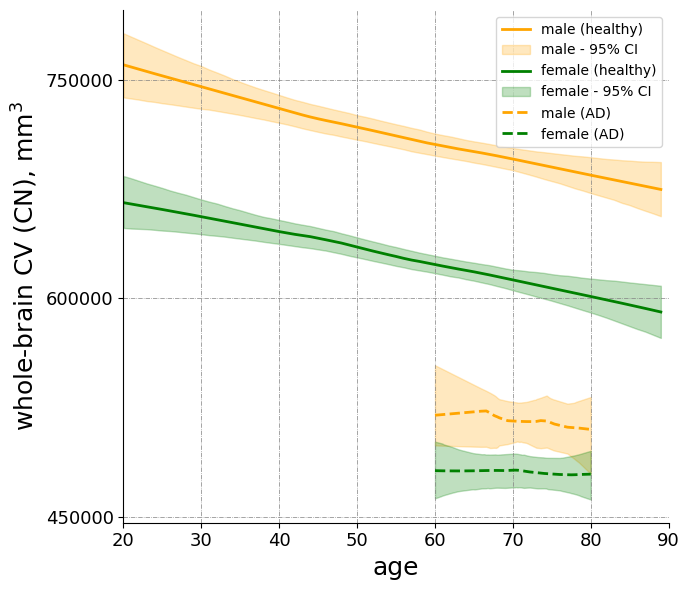

In [11]:
# Plot the the smoothed curve, and the confidence intervals
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Helvetica Neue']

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='orange', linewidth=2)
ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='orange', alpha=0.25, label='male - 95% CI')
ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='green', linewidth=2)
ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='green', alpha=0.25, label='female - 95% CI')

ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (AD)', color='orange', linewidth=2, linestyle='--', )
ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='orange', alpha=0.25)
ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (AD)', color='green', linewidth=2, linestyle='--')
ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='green', alpha=0.25)


ax.set_xlabel('age', fontsize=18)
ax.set_ylabel('whole-brain CV (CN), mm$^3$', fontsize=18)
ax.set_xlim((20,90))
#ax.set_ylim((460000, 850000))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
plt.setp(ax.get_xticklabels(), fontsize=13)
plt.setp(ax.get_yticklabels(), fontsize=13)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_AD_whole_CV.png', dpi=500, bbox_inches='tight')
plt.show()

####  CV Curves in 4 typical regions, healthy subjects vs subjects with AD

number of male subjects: 424
number of female subjects: 462
number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 42
number of subjects after filtering: 69
number of male subjects: 424
number of female subjects: 462
number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 44
number of subjects after filtering: 70
number of male subjects: 424
number of female subjects: 462
number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 43
number of subjects after filtering: 71
number of male subjects: 424
number of female subjects: 462
number of male subjects: 45
number of female subjects: 74
number of subjects after filtering: 42
number of subjects after filtering: 69


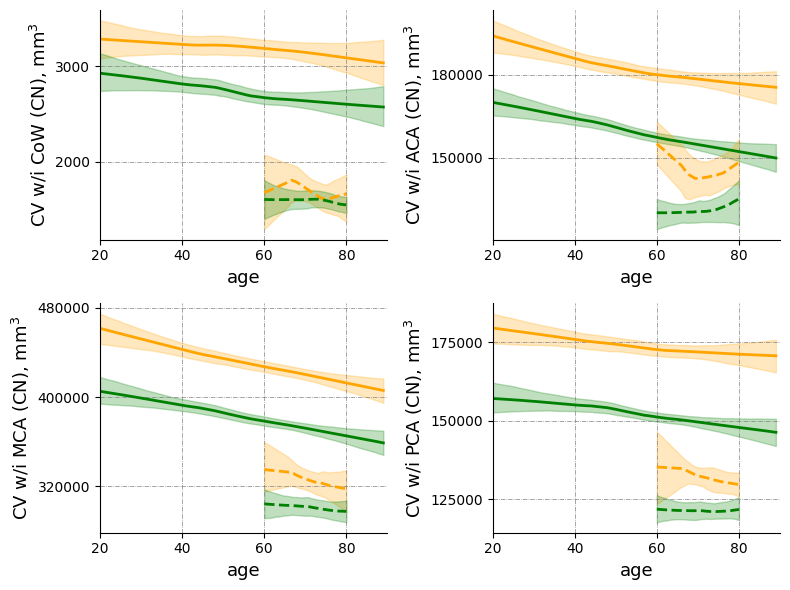

In [12]:
fig = plt.figure(figsize=(8, 6))
column_names = ['CoW', 'ACA', 'MCA', 'PCA']
for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(2, 2, idx+1)
    health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name=column_name.upper())
    # Apply LOESS smoothing
    # Fraction of data used for smoothing
    y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac = 0.75)
    y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac = 0.75)
    ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='orange', linewidth=2)
    ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='orange', alpha=0.25, label='male - 95% CI')

    ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='green', linewidth=2)
    ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='green', alpha=0.25, label='female - 95% CI')



    unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name=column_name.upper())

    unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
    unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)
    y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac = 0.85)
    y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac = 0.85)

    unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
    unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

    ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (AD)', color='orange', linewidth=2, linestyle='--', )
    ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='orange', alpha=0.25)

    ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (AD)', color='green', linewidth=2, linestyle='--')
    ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='green', alpha=0.25)
    
    ax.set_xlabel('age', fontsize=13)
    ax.set_ylabel('CV w/i ' + column_name + ' (CN), mm$^3$', fontsize=13)
    ax.axes.tick_params(labelsize=10)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_AD_4R_CV.png', dpi=500, bbox_inches='tight')
plt.show()    

## CV Curves for CN healthy subjects vs CN subjects with large territorial stroke

In [13]:
# load healthy params 
health_param_file = './data/chinese_cortical_volume.csv'
health_param_data = pd.read_csv(health_param_file)
health_param_data = health_param_data.dropna()
health_param_data

,cv,COW,ACA,MCA,PCA,PSC1,PSC2,PSC3,PMC,SAC,...,AC1,AC2,PGC,POper,PT,DPC2,Porb,RA,age,sex
0,605485.2248,2753.332410,145720.9090,375858.0051,155623.0598,0.000000,4717.235540,11447.60365,8233.624314,4093.076533,...,6062.254246,4156.371531,1531.387311,5434.578850,7822.206828,5729.955507,22332.58510,94457.23525,88,1
1,693727.7413,4208.625132,172132.2509,419342.4447,175831.6013,10.340602,4867.838528,11547.86761,10500.881630,3673.498963,...,4666.196783,5439.156804,2626.512982,7946.752860,10503.466780,10317.335930,23193.97094,92062.38219,84,1
2,596050.0059,2473.747211,155250.0542,357110.9914,144590.2608,79.117715,4196.755219,11929.19320,10418.923930,3412.610759,...,3966.434761,3468.872245,1731.798865,6440.181972,8660.752497,6911.371917,20276.99118,78752.01499,77,1
3,689515.5938,4103.439174,170069.1319,414995.7943,176341.0094,0.000000,5428.127214,10417.50425,11804.067320,3794.064048,...,4294.689252,4806.564461,2008.125819,7948.128243,9914.066545,7672.503130,21794.07139,89249.09891,42,2
4,707777.9411,3151.298131,192081.8324,420722.8594,174451.1079,496.348844,5209.077715,12946.43236,16681.974440,6240.552657,...,4635.174364,4617.078312,1501.972284,6540.430084,10061.404700,9526.278600,20960.39807,90725.84735,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,727044.9211,4630.003142,180329.7036,439211.7665,177767.8202,15.510898,5327.993566,13665.10140,13047.250620,4692.046735,...,4849.740868,5449.495602,2913.463730,8903.255623,11064.440790,9606.416346,24349.52518,98920.75390,43,1
882,762888.1481,4182.772933,197652.8246,453001.0300,190616.0459,31.021802,5459.837104,12734.44961,11366.905180,5084.990333,...,5814.002674,5793.321473,1931.107158,8515.484575,11873.594610,10079.500410,26001.44015,103907.52490,68,1
883,606907.2686,1782.989803,145822.1057,361759.2469,146340.5419,43.074818,4376.709224,11424.05719,8522.660492,3849.042699,...,3802.891108,4433.629520,1987.595191,5647.416366,9728.755407,7035.040872,18806.77338,82592.88746,53,2
884,699686.7309,3359.884568,163629.7630,423426.9912,172327.9257,50.767487,4776.758967,10655.01855,10556.560400,4349.081353,...,5022.904357,6521.314416,1461.488251,7113.601760,11494.989690,9813.509002,24766.84142,93092.18635,49,1


In [14]:
unhealth_param_file = './data/large-territorial-stroke_chinese_cortical_volume.csv'
unhealth_param_data = pd.read_csv(unhealth_param_file)
unhealth_param_data = unhealth_param_data.dropna()
unhealth_param_data

,cv,COW,ACA,MCA,PCA,age,sex
0,737045.7633,3315.279057,229734.2237,454527.0664,200389.0042,75,1
1,530317.5900,1212.274049,158103.3045,330161.6064,146880.5391,68,2
2,589123.2840,1423.017965,170286.7909,369124.7066,154613.5941,71,2
3,592998.2226,1850.691663,161902.4450,373736.6433,159737.9203,63,1
4,492968.7366,1923.062992,142426.6606,304708.5619,138039.0000,71,2
...,...,...,...,...,...,...,...
160,584980.5015,2138.418381,159689.0848,366615.6778,159581.3947,74,2
161,570174.5924,2025.674773,164025.3719,355938.7713,148874.2389,71,2
162,596726.3864,2384.530246,178685.9278,363639.3241,162300.3590,70,1
163,580984.9696,2610.743169,155572.2932,364297.9019,157323.0449,81,1


#### whole-brain CV curves, healthy subjects vs subjects with large territorial stroke

In [15]:
## whole-brain AV  
health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name='cv')
# Apply LOESS smoothing
frac = 0.75 # Fraction of data used for smoothing
y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac)
y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac)

number of male subjects: 424
number of female subjects: 462


In [16]:
## whole-brain AV  
unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name='cv')

unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)

# Apply LOESS smoothing
frac = 0.85 # Fraction of data used for smoothing
y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac, 1000)
y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac, 1000)

unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 97
number of subjects after filtering: 61


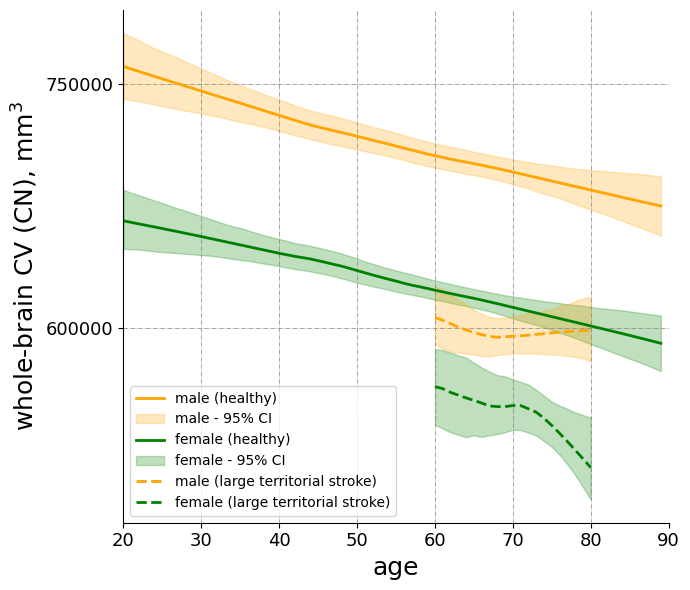

In [17]:
# Plot the the smoothed curve, and the confidence intervals
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Helvetica Neue']

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='orange', linewidth=2)
ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='orange', alpha=0.25, label='male - 95% CI')
ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='green', linewidth=2)
ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='green', alpha=0.25, label='female - 95% CI')

ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (large territorial stroke)', color='orange', linewidth=2, linestyle='--', )
ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='orange', alpha=0.25)
ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (large territorial stroke)', color='green', linewidth=2, linestyle='--')
ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='green', alpha=0.25)


ax.set_xlabel('age', fontsize=18)
ax.set_ylabel('whole-brain CV (CN), mm$^3$', fontsize=18)
ax.set_xlim((20,90))
#ax.set_ylim((460000, 850000))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
plt.setp(ax.get_xticklabels(), fontsize=13)
plt.setp(ax.get_yticklabels(), fontsize=13)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_largeterritorialstroke_whole_CV.png', dpi=500, bbox_inches='tight')
plt.show()

####  CV Curves in 4 typical regions, healthy subjects vs subjects with large territorial stroke

number of male subjects: 424
number of female subjects: 462
number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 101
number of subjects after filtering: 60
number of male subjects: 424
number of female subjects: 462
number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 98
number of subjects after filtering: 60
number of male subjects: 424
number of female subjects: 462
number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 99
number of subjects after filtering: 61
number of male subjects: 424
number of female subjects: 462
number of male subjects: 103
number of female subjects: 62
number of subjects after filtering: 98
number of subjects after filtering: 60


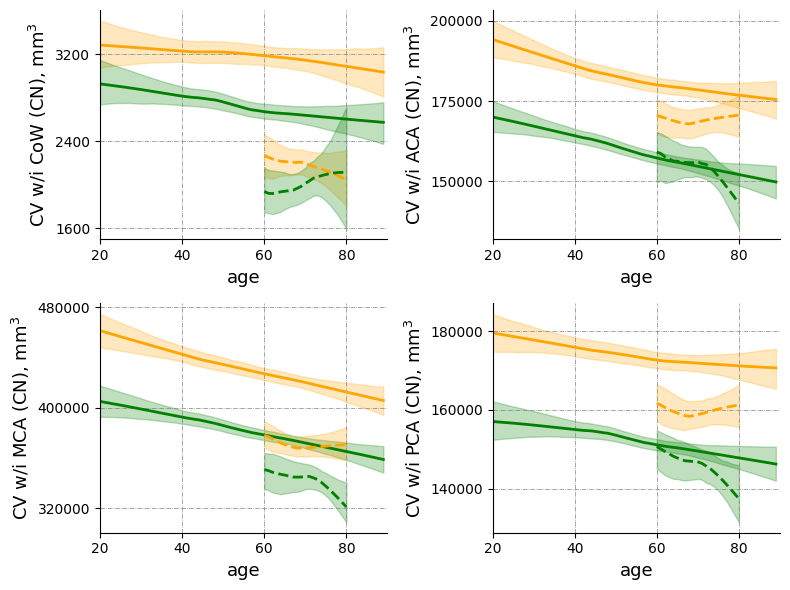

In [18]:
fig = plt.figure(figsize=(8, 6))
column_names = ['CoW', 'ACA', 'MCA', 'PCA']
for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(2, 2, idx+1)
    health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name=column_name.upper())
    # Apply LOESS smoothing
    # Fraction of data used for smoothing
    y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac = 0.75)
    y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac = 0.75)
    ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='orange', linewidth=2)
    ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='orange', alpha=0.25, label='male - 95% CI')

    ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='green', linewidth=2)
    ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='green', alpha=0.25, label='female - 95% CI')



    unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name=column_name.upper())

    unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
    unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)
    y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac = 0.85)
    y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac = 0.85)

    unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
    unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

    ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (large territorial stroke)', color='orange', linewidth=2, linestyle='--', )
    ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='orange', alpha=0.25)

    ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (large territorial stroke)', color='green', linewidth=2, linestyle='--')
    ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='green', alpha=0.25)
    
    ax.set_xlabel('age', fontsize=13)
    ax.set_ylabel('CV w/i ' + column_name + ' (CN), mm$^3$', fontsize=13)
    ax.axes.tick_params(labelsize=10)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_largeterritorialstroke_4R_CV.png', dpi=500, bbox_inches='tight')
plt.show()    

## CV curves for CN healthy subjects vs CN subjects with lacunar stroke

In [19]:
# load healthy params 
health_param_file = './data/chinese_cortical_volume.csv'
health_param_data = pd.read_csv(health_param_file)
health_param_data = health_param_data.dropna()
health_param_data

,cv,COW,ACA,MCA,PCA,PSC1,PSC2,PSC3,PMC,SAC,...,AC1,AC2,PGC,POper,PT,DPC2,Porb,RA,age,sex
0,605485.2248,2753.332410,145720.9090,375858.0051,155623.0598,0.000000,4717.235540,11447.60365,8233.624314,4093.076533,...,6062.254246,4156.371531,1531.387311,5434.578850,7822.206828,5729.955507,22332.58510,94457.23525,88,1
1,693727.7413,4208.625132,172132.2509,419342.4447,175831.6013,10.340602,4867.838528,11547.86761,10500.881630,3673.498963,...,4666.196783,5439.156804,2626.512982,7946.752860,10503.466780,10317.335930,23193.97094,92062.38219,84,1
2,596050.0059,2473.747211,155250.0542,357110.9914,144590.2608,79.117715,4196.755219,11929.19320,10418.923930,3412.610759,...,3966.434761,3468.872245,1731.798865,6440.181972,8660.752497,6911.371917,20276.99118,78752.01499,77,1
3,689515.5938,4103.439174,170069.1319,414995.7943,176341.0094,0.000000,5428.127214,10417.50425,11804.067320,3794.064048,...,4294.689252,4806.564461,2008.125819,7948.128243,9914.066545,7672.503130,21794.07139,89249.09891,42,2
4,707777.9411,3151.298131,192081.8324,420722.8594,174451.1079,496.348844,5209.077715,12946.43236,16681.974440,6240.552657,...,4635.174364,4617.078312,1501.972284,6540.430084,10061.404700,9526.278600,20960.39807,90725.84735,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,727044.9211,4630.003142,180329.7036,439211.7665,177767.8202,15.510898,5327.993566,13665.10140,13047.250620,4692.046735,...,4849.740868,5449.495602,2913.463730,8903.255623,11064.440790,9606.416346,24349.52518,98920.75390,43,1
882,762888.1481,4182.772933,197652.8246,453001.0300,190616.0459,31.021802,5459.837104,12734.44961,11366.905180,5084.990333,...,5814.002674,5793.321473,1931.107158,8515.484575,11873.594610,10079.500410,26001.44015,103907.52490,68,1
883,606907.2686,1782.989803,145822.1057,361759.2469,146340.5419,43.074818,4376.709224,11424.05719,8522.660492,3849.042699,...,3802.891108,4433.629520,1987.595191,5647.416366,9728.755407,7035.040872,18806.77338,82592.88746,53,2
884,699686.7309,3359.884568,163629.7630,423426.9912,172327.9257,50.767487,4776.758967,10655.01855,10556.560400,4349.081353,...,5022.904357,6521.314416,1461.488251,7113.601760,11494.989690,9813.509002,24766.84142,93092.18635,49,1


In [20]:
unhealth_param_file = './data/lacunar-stroke_chinese_cortical_volume.csv'
unhealth_param_data = pd.read_csv(unhealth_param_file)
unhealth_param_data = unhealth_param_data.dropna()
unhealth_param_data

,cv,COW,ACA,MCA,PCA,age,sex
0,606205.6099,2338.406029,165260.6924,380546.3512,166722.1962,78,1
1,599783.6796,2083.030929,154979.6549,380717.7474,163737.9231,65,1
2,701215.2679,1109.220850,208936.5931,447686.7658,192650.5849,68,1
3,476917.8736,1662.809883,128754.9120,307189.8405,126857.8230,72,2
4,550373.8585,2213.108251,150838.2094,345496.9223,149205.9821,75,2
...,...,...,...,...,...,...,...
329,555262.2554,2370.680334,151991.2236,346023.9477,144191.5161,52,2
330,616651.7912,1741.493555,172637.0868,383403.9596,167738.7516,77,1
331,516423.0173,1916.831489,180477.5305,334031.7320,113123.8256,74,1
332,650661.0059,3155.314887,173154.6351,412761.6478,165794.7977,66,1


#### whole-brain CV curves, healthy subjects vs subjects with lacunar stroke

In [21]:
## whole-brain AV  
health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name='cv')
# Apply LOESS smoothing
frac = 0.75 # Fraction of data used for smoothing
y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac)
y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac)

number of male subjects: 424
number of female subjects: 462


In [22]:
## whole-brain AV  
unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name='cv')

unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)

# Apply LOESS smoothing
frac = 0.85 # Fraction of data used for smoothing
y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac, 1000)
y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac, 1000)

unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 206
number of subjects after filtering: 111


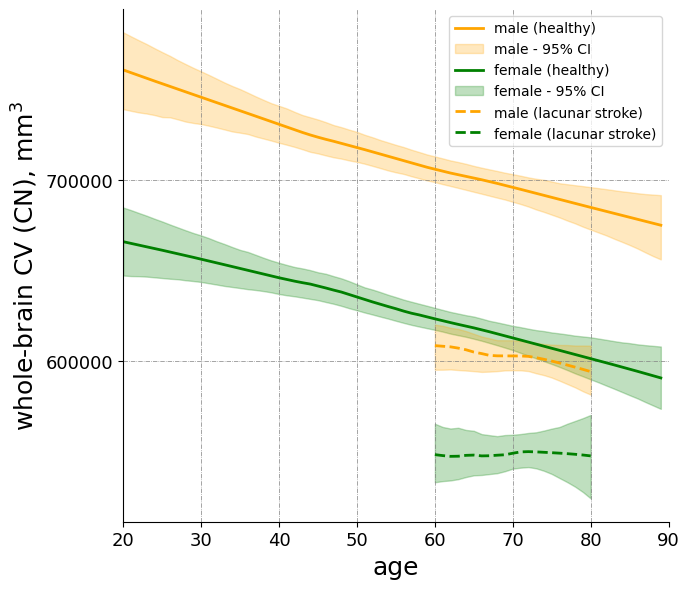

In [23]:
# Plot the the smoothed curve, and the confidence intervals
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Helvetica Neue']

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='orange', linewidth=2)
ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='orange', alpha=0.25, label='male - 95% CI')
ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='green', linewidth=2)
ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='green', alpha=0.25, label='female - 95% CI')

ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (lacunar stroke)', color='orange', linewidth=2, linestyle='--', )
ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='orange', alpha=0.25)
ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (lacunar stroke)', color='green', linewidth=2, linestyle='--')
ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='green', alpha=0.25)


ax.set_xlabel('age', fontsize=18)
ax.set_ylabel('whole-brain CV (CN), mm$^3$', fontsize=18)
ax.set_xlim((20,90))
#ax.set_ylim((460000, 850000))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
plt.setp(ax.get_xticklabels(), fontsize=13)
plt.setp(ax.get_yticklabels(), fontsize=13)
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_lacunar_whole_CV.png', dpi=500, bbox_inches='tight')
plt.show()

####  CV curves in 4 typical regions, healthy subjects vs subjects with lanunar stroke

number of male subjects: 424
number of female subjects: 462
number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 209
number of subjects after filtering: 113
number of male subjects: 424
number of female subjects: 462
number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 208
number of subjects after filtering: 108
number of male subjects: 424
number of female subjects: 462
number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 206
number of subjects after filtering: 111
number of male subjects: 424
number of female subjects: 462
number of male subjects: 217
number of female subjects: 117
number of subjects after filtering: 205
number of subjects after filtering: 112


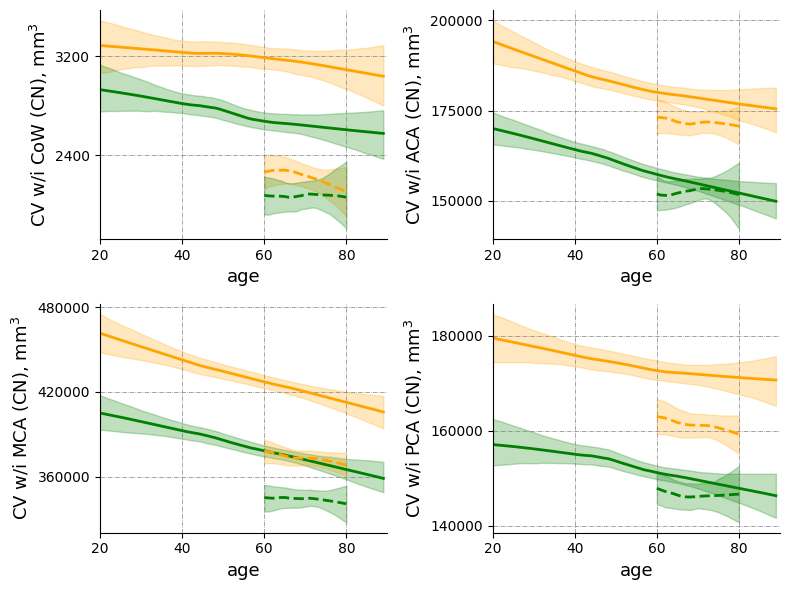

In [24]:
fig = plt.figure(figsize=(8, 6))
column_names = ['CoW', 'ACA', 'MCA', 'PCA']
for idx, column_name in enumerate(column_names):
    ax = fig.add_subplot(2, 2, idx+1)
    health_param_male, health_age_male, health_param_female, health_age_female = prepare_sample(health_param_data, column_name=column_name.upper())
    # Apply LOESS smoothing
    # Fraction of data used for smoothing
    y_smoothed_male_health, lower_bound_male_health, upper_bound_male_health = lowess_fit(health_age_male, health_param_male, frac = 0.75)
    y_smoothed_female_health, lower_bound_female_health, upper_bound_female_health = lowess_fit(health_age_female, health_param_female, frac = 0.75)
    ax.plot(health_age_male, y_smoothed_male_health, label='male (healthy)', color='orange', linewidth=2)
    ax.fill_between(health_age_male, lower_bound_male_health, upper_bound_male_health, color='orange', alpha=0.25, label='male - 95% CI')

    ax.plot(health_age_female, y_smoothed_female_health, label='female (healthy)', color='green', linewidth=2)
    ax.fill_between(health_age_female, lower_bound_female_health, upper_bound_female_health, color='green', alpha=0.25, label='female - 95% CI')



    unhealth_param_male, unhealth_age_male, unhealth_param_female, unhealth_age_female = prepare_sample(unhealth_param_data, column_name=column_name.upper())

    unhealth_param_male_filtered, unhealth_age_male_filtered = filter_samples(unhealth_param_male, unhealth_age_male, threshold=2.0)
    unhealth_param_female_filtered, unhealth_age_female_filtered = filter_samples(unhealth_param_female, unhealth_age_female, threshold=2.0)
    y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = lowess_fit(unhealth_age_male_filtered, unhealth_param_male_filtered, frac = 0.85)
    y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = lowess_fit(unhealth_age_female_filtered, unhealth_param_female_filtered, frac = 0.85)

    unhealth_age_male_filtered, y_smoothed_male_unhealth, lower_bound_male_unhealth, upper_bound_male_unhealth = crop_age_range_line(unhealth_age_male_filtered, y_smoothed_male_unhealth, 
                                                                                                                                 lower_bound_male_unhealth, upper_bound_male_unhealth)
    unhealth_age_female_filtered, y_smoothed_female_unhealth, lower_bound_female_unhealth, upper_bound_female_unhealth = crop_age_range_line(unhealth_age_female_filtered, y_smoothed_female_unhealth, 
                                                                                                                                 lower_bound_female_unhealth, upper_bound_female_unhealth)

    ax.plot(unhealth_age_male_filtered, y_smoothed_male_unhealth, label='male (lacunar stroke)', color='orange', linewidth=2, linestyle='--', )
    ax.fill_between(unhealth_age_male_filtered, lower_bound_male_unhealth, upper_bound_male_unhealth, color='orange', alpha=0.25)

    ax.plot(unhealth_age_female_filtered, y_smoothed_female_unhealth, label='female (lacunar stroke)', color='green', linewidth=2, linestyle='--')
    ax.fill_between(unhealth_age_female_filtered, lower_bound_female_unhealth, upper_bound_female_unhealth, color='green', alpha=0.25)
    
    ax.set_xlabel('age', fontsize=13)
    ax.set_ylabel('CV w/i ' + column_name + ' (CN), mm$^3$', fontsize=13)
    ax.axes.tick_params(labelsize=10)
    ax.set_xlim((20,90))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.grid(True, linestyle='-.', color='gray', linewidth=0.5)
    
plt.tight_layout()
plt.savefig('./plots/CN_health_vs_lacunarstroke_4R_CV.png', dpi=500, bbox_inches='tight')
plt.show()    